<a href="https://colab.research.google.com/github/aryanaroras/ARYAN-ARORA/blob/main/EDA_Phase1_23BDS0320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fall Semester 2026-27**

**Course Code: BCSE331L - Exploratory Data Analysis**

**Name: ARYAN ARORA**

**Registration Number: 23BDS0320**

**Date: 07 August 2026**

# **Phase 1 - EDA on the Household Income Dataset**

The dataset has 14 columns describing households: income, age, education, occupation, family size and housing.

Every column is text. Income and age are stored as ranges like `[50.000-75.000)` and `45-54`, and family counts are stored as words like `Three`. So the bands have to be converted to numbers before any statistics or plots are possible.

Phase 1 tasks covered below: loading, basic statistics, missing data, cleaning, transformation, and univariate, bivariate and multivariate analysis with 3 plots each.

## **1. Loading the Dataset**

The file is read directly from its raw GitHub link so the notebook runs anywhere without a local copy. Pandas reads the text `NA` in the file as a missing value automatically.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

BLUE, RED, GOLD, GREEN, PURPLE, TEAL = "#2F4B7C", "#EF5B5B", "#FFA600", "#5B8C5A", "#8E6C88", "#3C9AB2"
PALETTE = [BLUE, RED, GOLD, GREEN, PURPLE, TEAL]
SEQ = sns.blend_palette(["#EDF2F7", BLUE], as_cmap=True)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 9.5})

URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/income.csv"
income_raw = pd.read_csv(URL)

print("Rows:", income_raw.shape[0])
print("Columns:", income_raw.shape[1])
income_raw.head()

Rows: 8993
Columns: 14


,INCOME,SEX,MARITAL.STATUS,AGE,EDUCATION,OCCUPATION,AREA,DUAL.INCOMES,HOUSEHOLD.SIZE,UNDER18,HOUSEHOLDER,HOME.TYPE,ETHNIC.CLASS,LANGUAGE
0,[75.000-,F,Married,45-54,1 to 3 years of college,Homemaker,10+ years,No,Three,NaN,Own,House,White,NaN
1,[75.000-,M,Married,45-54,College graduate,Homemaker,10+ years,No,Five,Two,Own,House,White,English
2,[75.000-,F,Married,25-34,College graduate,Professional/Managerial,10+ years,Yes,Three,One,Rent,Apartment,White,English
3,-10.000),F,Single,14-17,Grades 9 to 11,"Student, HS or College",10+ years,Not Married,Four,Two,Family,House,White,English
4,-10.000),F,Single,14-17,Grades 9 to 11,"Student, HS or College",4-6 years,Not Married,Four,Two,Family,House,White,English


Column names contain dots (`MARITAL.STATUS`). They are replaced with underscores, and a copy is used for all work so the original stays untouched.

In [ ]:
df = income_raw.copy()
df.columns = [c.strip().replace(".", "_").upper() for c in df.columns]
df.columns.tolist()

['INCOME',
 'SEX',
 'MARITAL_STATUS',
 'AGE',
 'EDUCATION',
 'OCCUPATION',
 'AREA',
 'DUAL_INCOMES',
 'HOUSEHOLD_SIZE',
 'UNDER18',
 'HOUSEHOLDER',
 'HOME_TYPE',
 'ETHNIC_CLASS',
 'LANGUAGE']

## **2. Basic Statistical Analysis**

All columns are object type, so `describe()` gives count, unique, top and frequency instead of mean and standard deviation.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8993 entries, 0 to 8992
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   INCOME          8993 non-null   object
 1   SEX             8993 non-null   object
 2   MARITAL_STATUS  8833 non-null   object
 3   AGE             8993 non-null   object
 4   EDUCATION       8907 non-null   object
 5   OCCUPATION      8857 non-null   object
 6   AREA            8080 non-null   object
 7   DUAL_INCOMES    8993 non-null   object
 8   HOUSEHOLD_SIZE  8618 non-null   object
 9   UNDER18         3269 non-null   object
 10  HOUSEHOLDER     8753 non-null   object
 11  HOME_TYPE       8636 non-null   object
 12  ETHNIC_CLASS    8925 non-null   object
 13  LANGUAGE        8634 non-null   object
dtypes: object(14)
memory usage: 983.7+ KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq
INCOME,8993,9,-10.000),1745
SEX,8993,2,F,4918
MARITAL_STATUS,8833,5,Single,3654
AGE,8993,7,25-34,2249
EDUCATION,8907,6,1 to 3 years of college,3066
OCCUPATION,8857,9,Professional/Managerial,2820
AREA,8080,5,10+ years,5182
DUAL_INCOMES,8993,3,Not Married,5438
HOUSEHOLD_SIZE,8618,9,Two,2664
UNDER18,3269,9,One,1506


In [ ]:
overview = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "most_common": [df[c].mode().iat[0] for c in df.columns],
})
overview

,missing,missing_%,unique_values,most_common
INCOME,0,0.00,9,-10.000)
SEX,0,0.00,2,F
MARITAL_STATUS,160,1.78,5,Single
AGE,0,0.00,7,25-34
EDUCATION,86,0.96,6,1 to 3 years of college
OCCUPATION,136,1.51,9,Professional/Managerial
AREA,913,10.15,5,10+ years
DUAL_INCOMES,0,0.00,3,Not Married
HOUSEHOLD_SIZE,375,4.17,9,Two
UNDER18,5724,63.65,9,One


In [ ]:
for col in ["INCOME", "EDUCATION", "OCCUPATION"]:
    print(col)
    print(df[col].value_counts().to_string())
    print()

INCOME
INCOME
-10.000)           1745
[50.000-75.000)    1308
[30.000-40.000)    1110
[40.000-50.000)     969
[75.000-            884
[20.000-25.000)     813
[10.000-15.000)     775
[25.000-30.000)     722
[15.000-20.000)     667

EDUCATION
EDUCATION
1 to 3 years of college    3066
Graduated High Scool       2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264

OCCUPATION
OCCUPATION
Professional/Managerial          2820
Student, HS or College           1489
Clerical/Service Worker          1062
Sales Worker                      770
Factory Worker/Laborer/Driver     767
Retired                           690
Homemaker                         650
Unemployed                        337
Military                          272



Two points from the summary:

- No column is numeric, so a transformation step is needed before any real statistics.
- `LANGUAGE` and `ETHNIC_CLASS` are almost entirely one category, so they carry very little information.

## **3. Handling Missing Data**

First the amount of missing data is checked, then where it sits, and then whether the gaps appear together in the same rows.

In [ ]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
missing

,missing,missing_%
UNDER18,5724,63.65
AREA,913,10.15
HOUSEHOLD_SIZE,375,4.17
LANGUAGE,359,3.99
HOME_TYPE,357,3.97
HOUSEHOLDER,240,2.67
MARITAL_STATUS,160,1.78
OCCUPATION,136,1.51
EDUCATION,86,0.96
ETHNIC_CLASS,68,0.76


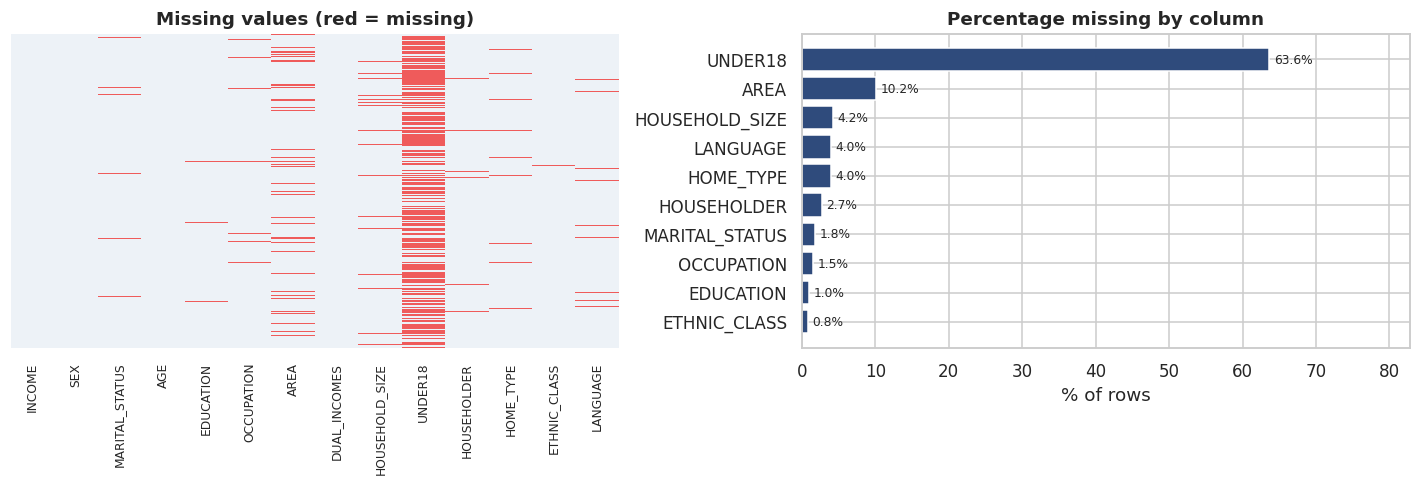

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(df.isna(), cbar=False, cmap=ListedColormap(["#EDF2F7", RED]), yticklabels=False, ax=axes[0])
axes[0].set_title("Missing values (red = missing)")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

bars = axes[1].barh(missing.index[::-1], missing["missing_%"][::-1], color=BLUE)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
axes[1].set_title("Percentage missing by column")
axes[1].set_xlabel("% of rows")
axes[1].set_xlim(0, missing["missing_%"].max() * 1.3)

plt.tight_layout()
plt.show()

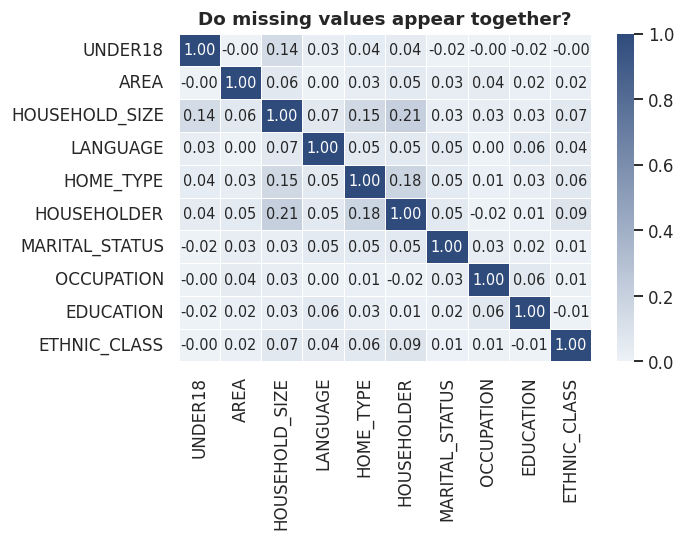

Rows with at least one missing value: 6393
Fully complete rows: 2600


In [ ]:
gaps = df[missing.index].isna().astype(int)

plt.figure(figsize=(6.5, 5))
sns.heatmap(gaps.corr(), annot=True, fmt=".2f", cmap=SEQ, vmin=0, vmax=1, linewidths=0.5, linecolor="white")
plt.title("Do missing values appear together?")
plt.tight_layout()
plt.show()

print("Rows with at least one missing value:", (df.isna().sum(axis=1) > 0).sum())
print("Fully complete rows:", (df.isna().sum(axis=1) == 0).sum())

The correlations are mostly low, so the missing values are scattered rather than one whole section being skipped. The housing columns are the exception, where the same respondents tend to leave several fields blank together.

Dropping every incomplete row would remove a large part of the sample, so a mixed approach is used:

- `INCOME` missing - drop the row, since it is the column being studied.
- More than 5% missing - fill with `"Unknown"`, so non-response stays visible.
- 5% or less missing - fill with the mode.

In [ ]:
work = df.dropna(subset=["INCOME"]).reset_index(drop=True)

rates = work.isna().mean()
unknown_cols = [c for c in work.columns if rates[c] > 0.05]
mode_cols = [c for c in work.columns if 0 < rates[c] <= 0.05]

for c in unknown_cols:
    work[c] = work[c].fillna("Unknown")
for c in mode_cols:
    work[c] = work[c].fillna(work[c].mode().iat[0])

print("Filled with 'Unknown':", unknown_cols)
print("Filled with mode:", mode_cols)
print("Missing values left:", int(work.isna().sum().sum()))

Filled with 'Unknown': ['AREA', 'UNDER18']
Filled with mode: ['MARITAL_STATUS', 'EDUCATION', 'OCCUPATION', 'HOUSEHOLD_SIZE', 'HOUSEHOLDER', 'HOME_TYPE', 'ETHNIC_CLASS', 'LANGUAGE']
Missing values left: 0


## **4. Data Cleaning**

Now the values that are present but wrong are checked: extra spaces, a spelling mistake, contradictions between columns, and impossible records.

In [ ]:
for c in work.select_dtypes(include="object").columns:
    work[c] = work[c].astype(str).str.strip()

print("Before:")
print(work["EDUCATION"].value_counts().to_string())

work["EDUCATION"] = work["EDUCATION"].replace({"Graduated High Scool": "Graduated High School"})

print()
print("After fixing the spelling:")
print(work["EDUCATION"].value_counts().to_string())

Before:
EDUCATION
1 to 3 years of college    3152
Graduated High Scool       2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264

After fixing the spelling:
EDUCATION
1 to 3 years of college    3152
Graduated High School      2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264


`DUAL_INCOMES` has the values `Yes`, `No` and `Not Married`, so it repeats information already present in `MARITAL_STATUS`. Rows where the two disagree are contradictions.

In [ ]:
married = work["MARITAL_STATUS"] == "Married"
conflict = married & (work["DUAL_INCOMES"] == "Not Married")

print("Contradictory rows:", conflict.sum())
pd.crosstab(work["MARITAL_STATUS"], work["DUAL_INCOMES"])

Contradictory rows: 93


DUAL_INCOMES,No,Not Married,Yes
MARITAL_STATUS,,,
Divorced,0,875,0
Married,1219,93,2022
Single,45,3727,42
Together,80,441,147
Widowed,0,302,0


In [ ]:
work["DUAL_INCOMES_CLEAN"] = work["DUAL_INCOMES"].where(~conflict, "Unclear")
work["DUAL_INCOMES_CLEAN"].value_counts()

,count
DUAL_INCOMES_CLEAN,
Not Married,5345
Yes,2211
No,1344
Unclear,93


Instead of guessing which column is correct, these rows are marked `Unclear`. The row is still usable for everything else.

Next, some records are logically impossible: a 14-17 year old cannot be retired, a college graduate, or widowed. These are removed.

In [ ]:
teen = work["AGE"] == "14-17"
impossible = teen & (
    work["EDUCATION"].isin(["College graduate", "Grad Study"])
    | work["OCCUPATION"].isin(["Retired", "Military"])
    | work["MARITAL_STATUS"].isin(["Married", "Divorced", "Widowed"])
)

print("Impossible rows found:", impossible.sum())
print(work.loc[impossible, ["AGE", "EDUCATION", "OCCUPATION", "MARITAL_STATUS"]].head().to_string())

work = work.loc[~impossible].reset_index(drop=True)
print()
print("Rows kept:", len(work))

Impossible rows found: 23
        AGE              EDUCATION               OCCUPATION MARITAL_STATUS
54    14-17       College graduate                  Retired        Married
608   14-17         Grades 9 to 11                Homemaker        Married
801   14-17         Grades 9 to 11  Professional/Managerial        Married
1613  14-17  Graduated High School             Sales Worker       Divorced
1668  14-17  Graduated High School                 Military         Single

Rows kept: 8970


In [ ]:
print("Exact duplicate rows:", work.duplicated().sum())

Exact duplicate rows: 776


Duplicate rows are kept here. With only 14 broad categorical columns, two different households can genuinely give the same answer to every question, so removing them would delete real respondents.

## **5. Data Transformation**

Each band is replaced by its midpoint and each word is replaced by its number, so the data can be used for statistics and plots. `INCOME`, `AGE` and `EDUCATION` are also set as ordered categories so charts follow the correct order instead of alphabetical order.

The two open bands (`< 10.000` and `75.000+`) are given the working values 5 and 87.5, so any number based on them is an estimate.

In [ ]:
income_order = ["-10.000)", "[10.000-15.000)", "[15.000-20.000)", "[20.000-25.000)", "[25.000-30.000)",
                "[30.000-40.000)", "[40.000-50.000)", "[50.000-75.000)", "[75.000-"]
income_label = dict(zip(income_order,
    ["< 10K", "10-15K", "15-20K", "20-25K", "25-30K", "30-40K", "40-50K", "50-75K", "75K +"]))
income_mid = dict(zip(income_order, [5, 12.5, 17.5, 22.5, 27.5, 35, 45, 62.5, 87.5]))

age_order = ["14-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_mid = dict(zip(age_order, [15.5, 21, 29.5, 39.5, 49.5, 59.5, 70]))

edu_order = ["Grade 8 or less", "Grades 9 to 11", "Graduated High School",
             "1 to 3 years of college", "College graduate", "Grad Study"]
edu_rank = {level: i + 1 for i, level in enumerate(edu_order)}

area_years = {"-1 year": 0.5, "1-3 years": 2, "4-6 years": 5, "7-10 years": 8.5, "10+ years": 12}

words = {"None": 0, "One": 1, "Two": 2, "Three": 3, "Four": 4,
         "Five": 5, "Six": 6, "Seven": 7, "Eight": 8, "Nine or more": 9}

tidy = work.copy()

tidy["INCOME_BAND"] = pd.Categorical(tidy["INCOME"].map(income_label),
                                     categories=[income_label[k] for k in income_order], ordered=True)
tidy["AGE_BAND"] = pd.Categorical(tidy["AGE"], categories=age_order, ordered=True)
tidy["EDU_BAND"] = pd.Categorical(tidy["EDUCATION"], categories=edu_order, ordered=True)

tidy["INCOME_K"] = tidy["INCOME"].map(income_mid)
tidy["AGE_YEARS"] = tidy["AGE"].map(age_mid)
tidy["EDU_RANK"] = tidy["EDUCATION"].map(edu_rank)
tidy["AREA_YEARS"] = tidy["AREA"].map(area_years)
tidy["HH_SIZE"] = tidy["HOUSEHOLD_SIZE"].map(words)
tidy["CHILDREN"] = tidy["UNDER18"].map(words)
tidy["OWNS_HOME"] = (tidy["HOUSEHOLDER"] == "Own").astype(int)

tidy.head(3)

,INCOME,SEX,MARITAL_STATUS,AGE,EDUCATION,OCCUPATION,AREA,DUAL_INCOMES,HOUSEHOLD_SIZE,UNDER18,...,INCOME_BAND,AGE_BAND,EDU_BAND,INCOME_K,AGE_YEARS,EDU_RANK,AREA_YEARS,HH_SIZE,CHILDREN,OWNS_HOME
0,[75.000-,F,Married,45-54,1 to 3 years of college,Homemaker,10+ years,No,Three,Unknown,...,75K +,45-54,1 to 3 years of college,87.5,49.5,4,12.0,3,NaN,1
1,[75.000-,M,Married,45-54,College graduate,Homemaker,10+ years,No,Five,Two,...,75K +,45-54,College graduate,87.5,49.5,5,12.0,5,2.0,1
2,[75.000-,F,Married,25-34,College graduate,Professional/Managerial,10+ years,Yes,Three,One,...,75K +,25-34,College graduate,87.5,29.5,5,12.0,3,1.0,0


In [ ]:
numeric_cols = ["INCOME_K", "AGE_YEARS", "EDU_RANK", "AREA_YEARS", "HH_SIZE", "CHILDREN", "OWNS_HOME"]

print("Values that could not be mapped:")
print(tidy[numeric_cols].isna().sum().to_string())

tidy[numeric_cols].describe().T.round(2)

Values that could not be mapped:
INCOME_K         0
AGE_YEARS        0
EDU_RANK         0
AREA_YEARS     909
HH_SIZE          0
CHILDREN      5720
OWNS_HOME        0


,count,mean,std,min,25%,50%,75%,max
INCOME_K,8970.0,34.49,25.52,5.0,12.5,27.5,45.0,87.5
AGE_YEARS,8970.0,34.67,15.32,15.5,21.0,29.5,39.5,70.0
EDU_RANK,8970.0,3.84,1.23,1.0,3.0,4.0,5.0,6.0
AREA_YEARS,8061.0,9.34,3.97,0.5,8.5,12.0,12.0,12.0
HH_SIZE,8970.0,2.81,1.51,1.0,2.0,2.0,4.0,9.0
CHILDREN,3250.0,1.83,1.04,1.0,1.0,2.0,2.0,9.0
OWNS_HOME,8970.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0


`AREA_YEARS` is the only column with gaps left, because those rows were filled with `Unknown` in step 3 and no number can be given to them. They are skipped wherever that column is used.

Statistics are now possible on income:

In [ ]:
print("Median income:", tidy["INCOME_K"].median(), "K")
print("Mean income:", round(tidy["INCOME_K"].mean(), 2), "K")
print("Standard deviation:", round(tidy["INCOME_K"].std(), 2))
print("Skew:", round(tidy["INCOME_K"].skew(), 2))

Median income: 27.5 K
Mean income: 34.49 K
Standard deviation: 25.52
Skew: 0.7


## **6. Univariate Analysis**

Each variable is looked at on its own. Three plots are given below.

### Plot 1 - Income distribution

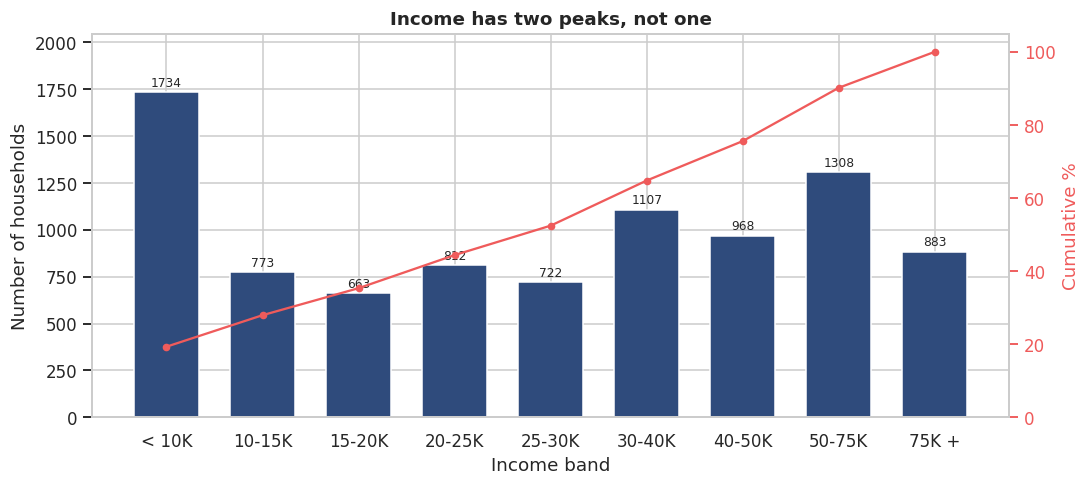

Households below 25K: 44.4 %
Households at 50K or above: 24.4 %


In [ ]:
counts = tidy["INCOME_BAND"].value_counts().sort_index()
cumulative = counts.cumsum() / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.68)
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("Income has two peaks, not one")
ax.set_xlabel("Income band")
ax.set_ylabel("Number of households")
ax.set_ylim(0, counts.max() * 1.18)

twin = ax.twinx()
twin.plot(counts.index.astype(str), cumulative.values, color=RED, marker="o", markersize=4)
twin.set_ylabel("Cumulative %", color=RED)
twin.tick_params(axis="y", colors=RED)
twin.set_ylim(0, 105)
twin.grid(False)

plt.tight_layout()
plt.show()

print("Households below 25K:", round((tidy["INCOME_K"] < 25).mean() * 100, 1), "%")
print("Households at 50K or above:", round((tidy["INCOME_K"] >= 50).mean() * 100, 1), "%")

The `< 10K` band and the `75K +` band are both large, so the distribution has two peaks. The reason for the low peak is checked in the bivariate section.

### Plot 2 - Age, education, occupation and home type

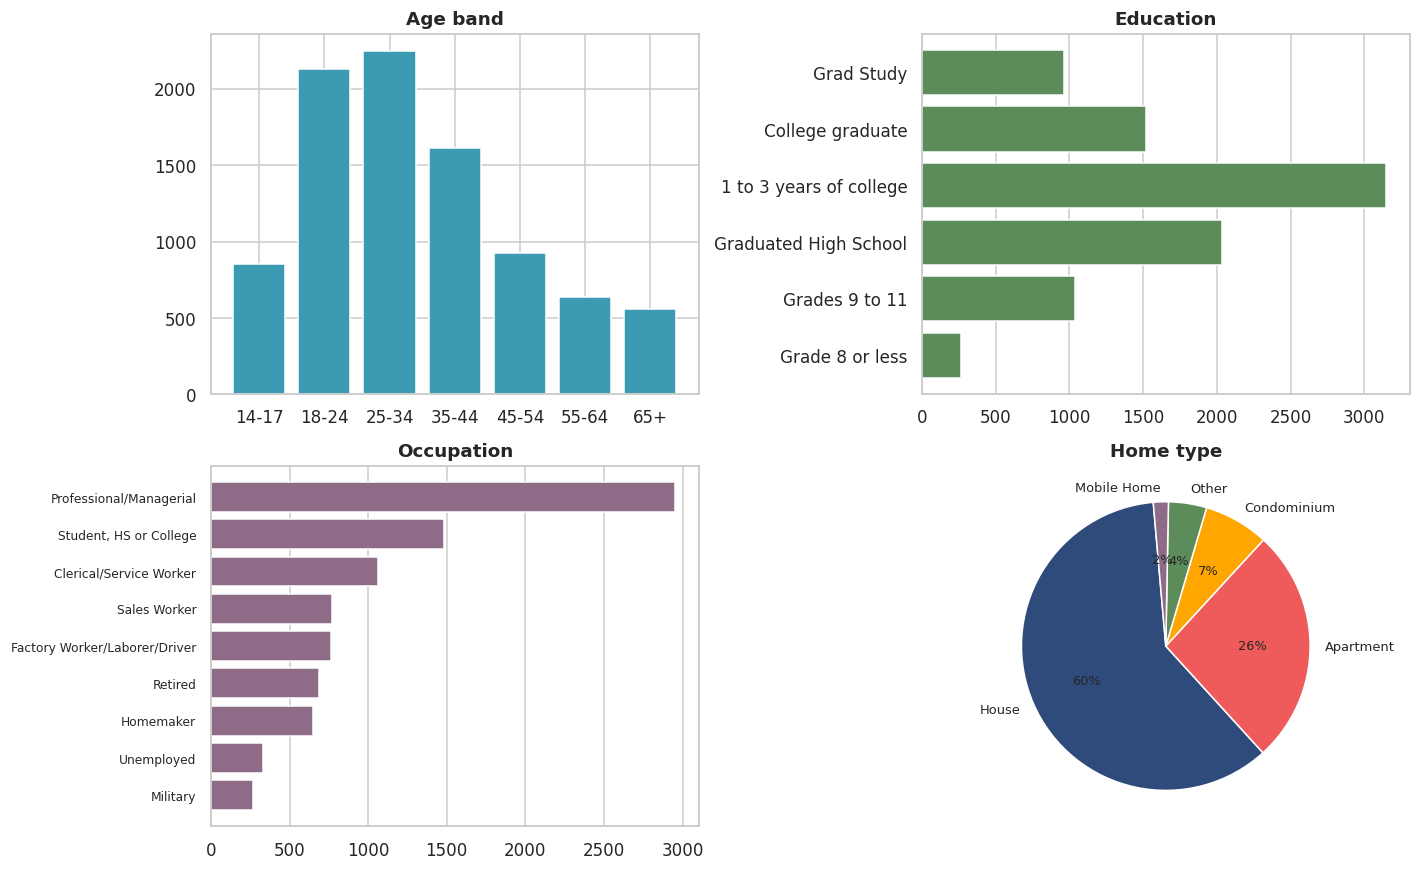

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

age_counts = tidy["AGE_BAND"].value_counts().sort_index()
axes[0, 0].bar(age_counts.index.astype(str), age_counts.values, color=TEAL)
axes[0, 0].set_title("Age band")

edu_counts = tidy["EDU_BAND"].value_counts().sort_index()
axes[0, 1].barh(edu_counts.index.astype(str), edu_counts.values, color=GREEN)
axes[0, 1].set_title("Education")
axes[0, 1].grid(axis="y", visible=False)

occ_counts = tidy["OCCUPATION"].value_counts().sort_values()
axes[1, 0].barh(occ_counts.index.astype(str), occ_counts.values, color=PURPLE)
axes[1, 0].set_title("Occupation")
axes[1, 0].grid(axis="y", visible=False)
axes[1, 0].tick_params(axis="y", labelsize=8)

home_counts = tidy["HOME_TYPE"].value_counts()
axes[1, 1].pie(home_counts.values, labels=home_counts.index.astype(str), autopct="%1.0f%%",
               colors=PALETTE, startangle=95, textprops={"fontsize": 8.5})
axes[1, 1].set_title("Home type")

plt.tight_layout()
plt.show()

### Plot 3 - Income and household size

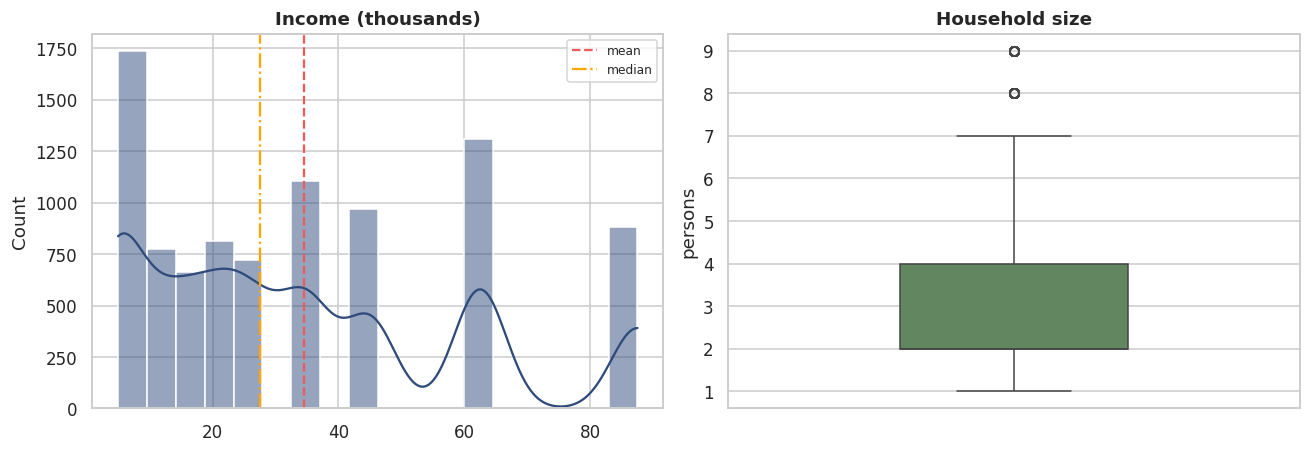

Most common household size: 2 persons


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(tidy["INCOME_K"], bins=18, kde=True, color=BLUE, edgecolor="white", ax=axes[0])
axes[0].axvline(tidy["INCOME_K"].mean(), color=RED, linestyle="--", label="mean")
axes[0].axvline(tidy["INCOME_K"].median(), color=GOLD, linestyle="-.", label="median")
axes[0].set_title("Income (thousands)")
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)

sns.boxplot(y=tidy["HH_SIZE"], color=GREEN, width=0.4, ax=axes[1])
axes[1].set_title("Household size")
axes[1].set_ylabel("persons")

plt.tight_layout()
plt.show()

print("Most common household size:", int(tidy["HH_SIZE"].mode().iat[0]), "persons")

The mean is higher than the median, which means a small number of high earners pull the average up.

## **7. Bivariate Analysis**

Income is now compared against other columns. Three plots are given below.

### Plot 4 - Income and education

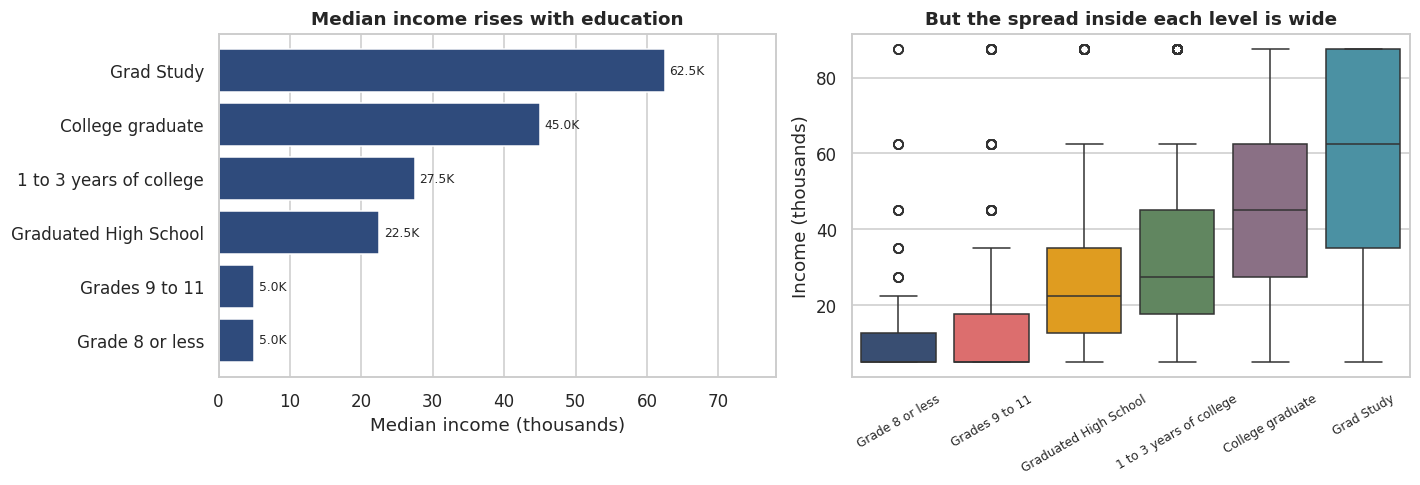

Spearman correlation between education rank and income: 0.452


In [ ]:
edu_median = tidy.groupby("EDU_BAND", observed=True)["INCOME_K"].median()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].barh(edu_median.index.astype(str), edu_median.values, color=BLUE)
axes[0].bar_label(bars, fmt="%.1fK", padding=3, fontsize=8)
axes[0].set_title("Median income rises with education")
axes[0].set_xlabel("Median income (thousands)")
axes[0].set_xlim(0, edu_median.max() * 1.25)
axes[0].grid(axis="y", visible=False)

sns.boxplot(data=tidy, x="EDU_BAND", y="INCOME_K", palette=PALETTE, ax=axes[1])
axes[1].set_title("But the spread inside each level is wide")
axes[1].set_xlabel("")
axes[1].set_ylabel("Income (thousands)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

print("Spearman correlation between education rank and income:",
      round(tidy["EDU_RANK"].corr(tidy["INCOME_K"], method="spearman"), 3))

Income increases at every education level, but the boxes overlap a lot, so education shifts income on average without deciding it for any one household.

### Plot 5 - Income across age groups

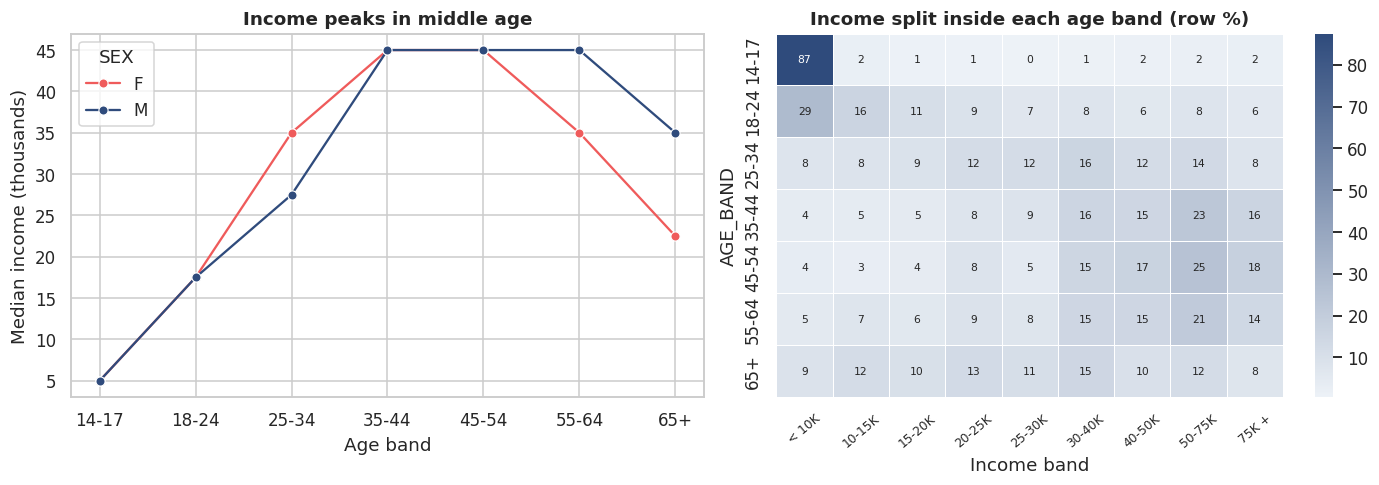

In [ ]:
life = tidy.groupby(["AGE_BAND", "SEX"], observed=True)["INCOME_K"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=life, x="AGE_BAND", y="INCOME_K", hue="SEX", marker="o", palette=[RED, BLUE], ax=axes[0])
axes[0].set_title("Income peaks in middle age")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("Median income (thousands)")

share = pd.crosstab(tidy["AGE_BAND"], tidy["INCOME_BAND"], normalize="index") * 100
sns.heatmap(share, cmap=SEQ, annot=True, fmt=".0f", linewidths=0.5, linecolor="white",
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("Income split inside each age band (row %)")
axes[1].set_xlabel("Income band")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)

plt.tight_layout()
plt.show()

This explains the low peak seen in Plot 1. Most of the `< 10K` households are in the 14-17 and 18-24 age bands, so they are students living with family, not low-earning workers. Income then rises till 35-54 and falls after 65.

### Plot 6 - Dual incomes and home ownership

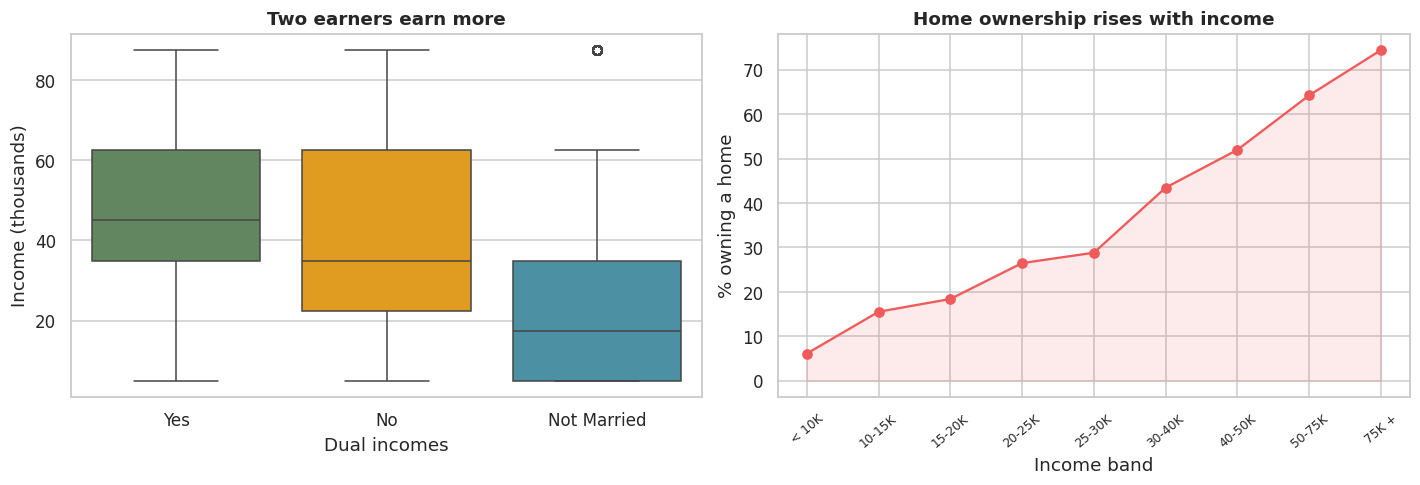

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dual = tidy[tidy["DUAL_INCOMES_CLEAN"].isin(["Yes", "No", "Not Married"])]
sns.boxplot(data=dual, x="DUAL_INCOMES_CLEAN", y="INCOME_K", order=["Yes", "No", "Not Married"],
            palette=[GREEN, GOLD, TEAL], ax=axes[0])
axes[0].set_title("Two earners earn more")
axes[0].set_xlabel("Dual incomes")
axes[0].set_ylabel("Income (thousands)")

own = tidy.groupby("INCOME_BAND", observed=True)["OWNS_HOME"].mean().mul(100)
axes[1].plot(own.index.astype(str), own.values, color=RED, marker="o")
axes[1].fill_between(own.index.astype(str), own.values, color=RED, alpha=0.12)
axes[1].set_title("Home ownership rises with income")
axes[1].set_xlabel("Income band")
axes[1].set_ylabel("% owning a home")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)

plt.tight_layout()
plt.show()

## **8. Multivariate Analysis**

Three or more variables are now looked at together. Three plots are given below.

### Plot 7 - Correlation between all numeric columns

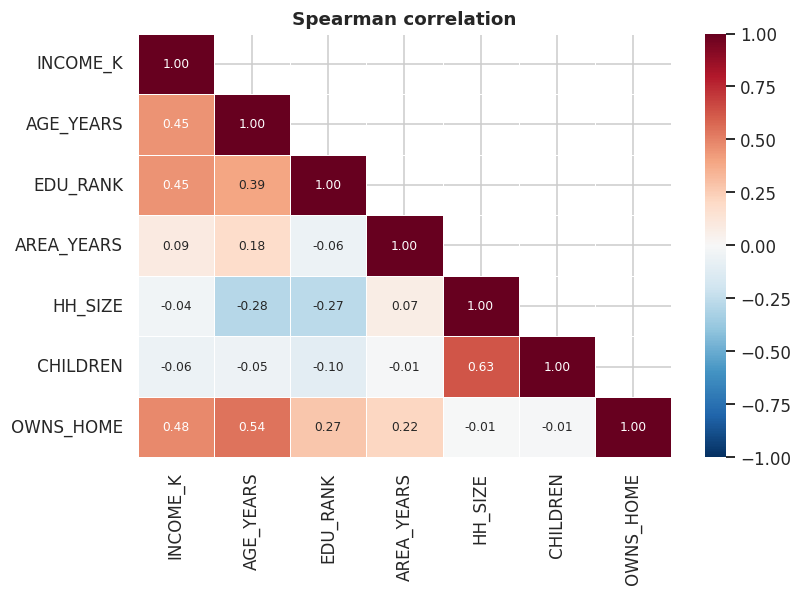

Correlation with income, strongest first:
OWNS_HOME     0.481
EDU_RANK      0.452
AGE_YEARS     0.446
AREA_YEARS    0.087
CHILDREN      0.058
HH_SIZE       0.035


In [ ]:
corr = tidy[numeric_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white", annot_kws={"size": 8})
plt.title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Correlation with income, strongest first:")
print(corr["INCOME_K"].drop("INCOME_K").abs().sort_values(ascending=False).round(3).to_string())

Spearman is used instead of Pearson because these values come from ordered bands, so ranks are more reliable than the exact midpoints chosen.

### Plot 8 - Education and occupation together

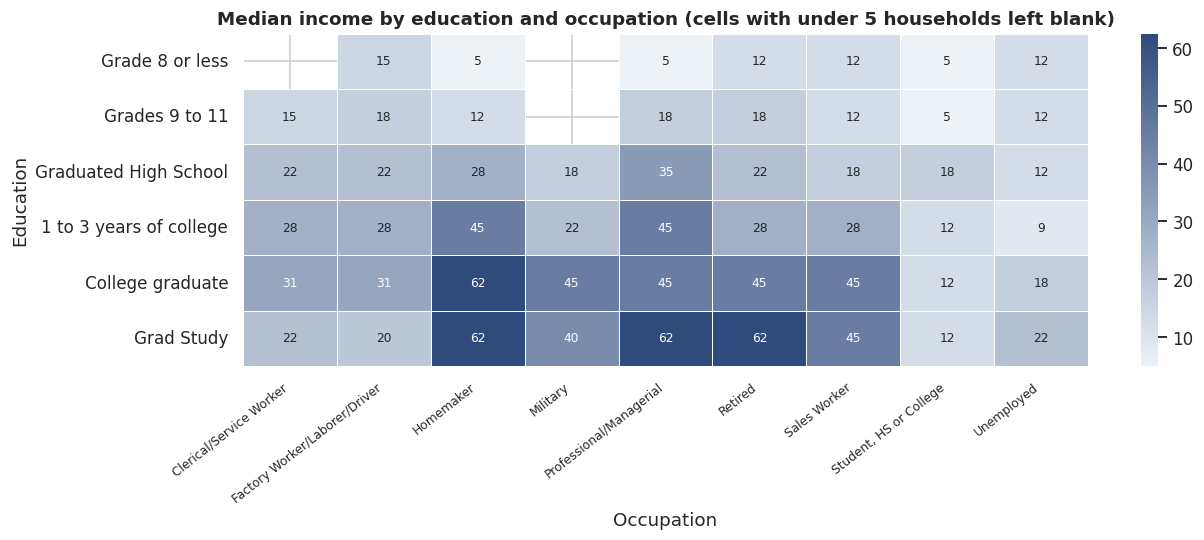

In [ ]:
grid = tidy.pivot_table(index="EDU_BAND", columns="OCCUPATION", values="INCOME_K",
                        aggfunc="median", observed=True)
count = tidy.pivot_table(index="EDU_BAND", columns="OCCUPATION", values="INCOME_K",
                         aggfunc="size", observed=True)
grid = grid.where(count >= 5)

plt.figure(figsize=(12, 5))
sns.heatmap(grid, cmap=SEQ, annot=True, fmt=".0f", linewidths=0.5, linecolor="white", annot_kws={"size": 8})
plt.title("Median income by education and occupation (cells with under 5 households left blank)")
plt.xlabel("Occupation")
plt.ylabel("Education")
plt.xticks(rotation=38, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Cells built from fewer than 5 households are left blank, because a median from 2 rows is not reliable enough to colour the same way as one from 80 rows.

The highest values sit where high education meets professional work, so the two factors add up rather than working separately.

### Plot 9 - Age, dual income and household size together

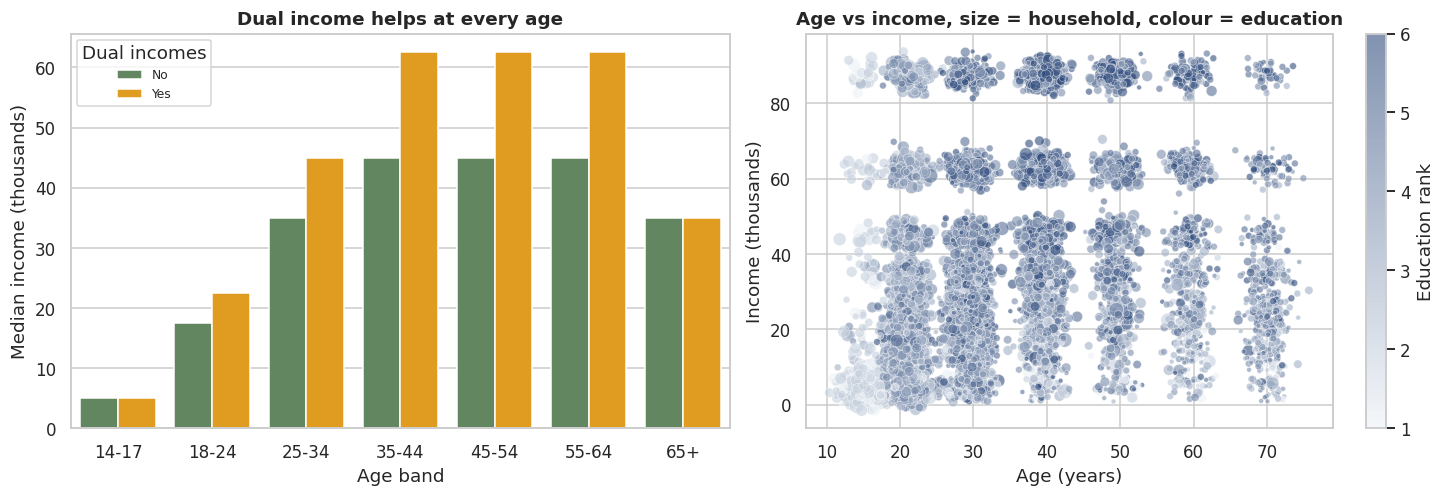

In [ ]:
combo = (tidy[tidy["DUAL_INCOMES_CLEAN"].isin(["Yes", "No"])]
         .groupby(["AGE_BAND", "DUAL_INCOMES_CLEAN"], observed=True)["INCOME_K"]
         .median().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

sns.barplot(data=combo, x="AGE_BAND", y="INCOME_K", hue="DUAL_INCOMES_CLEAN",
            palette=[GREEN, GOLD], errorbar=None, ax=axes[0])
axes[0].set_title("Dual income helps at every age")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("Median income (thousands)")
axes[0].legend(title="Dual incomes", fontsize=8)

rng = np.random.default_rng(23)
sample = tidy.dropna(subset=["AGE_YEARS", "INCOME_K", "HH_SIZE", "EDU_RANK"])
x = sample["AGE_YEARS"] + rng.normal(0, 1.5, len(sample))
y = sample["INCOME_K"] + rng.normal(0, 2.2, len(sample))

points = axes[1].scatter(x, y, c=sample["EDU_RANK"], s=sample["HH_SIZE"] * 10,
                         cmap=SEQ, alpha=0.6, edgecolor="white", linewidth=0.4)
axes[1].set_title("Age vs income, size = household, colour = education")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Income (thousands)")
plt.colorbar(points, ax=axes[1], label="Education rank")

plt.tight_layout()
plt.show()

A small random jitter is added to the scatter points only so they do not stack on top of each other. The actual values are unchanged.

## **9. Conclusion**

**About the data**

1. No column was numeric, so the transformation step was needed before any analysis could be done.
2. Missing values were mostly scattered, except in the housing columns where the same respondents left several fields blank.
3. Three problems were found and fixed: a spelling mistake in `EDUCATION`, contradictions between `MARITAL_STATUS` and `DUAL_INCOMES`, and impossible records such as retired teenagers.

**About the households**

4. Income has two peaks. The large `< 10K` group is mainly students living with family, which was only visible after comparing income with age.
5. Education is the strongest single factor, with median income rising at every level, though the spread within each level is wide.
6. Dual income gives a clear advantage in every age group.
7. Education and occupation combine, with the highest incomes where advanced education meets professional work.

**Limitations**

- All income and age values are band midpoints, so every number is an estimate.
- `ETHNIC_CLASS` and `LANGUAGE` are almost entirely one category, so no group comparison was done on them.
- These are only associations within one survey. No cause and effect is claimed.